# 07 · Dynamic pricing model — demand, counterfactual optimum, inflation policies

Parts 9 and 10 of the brief. Notebook 06b showed demand is close to
**inelastic** — the endogeneity-breaking estimates (2SLS strong first stage,
relative-price panel) put β in **[0, −0.6]**. So we:

1. Build a constant-elasticity demand model
   `Q(P) = Q₀·(P/P₀)^β` and show the revenue-max price is **degenerate**
   (at the grid boundary) whenever |β| < 1 — i.e. revenue optimisation alone
   just says "raise price", which is why the substantive question is *which
   inflation-indexation rule*.
2. Define pass-through policies **A/B** (index to CPI), **C** (partial `k·π`),
   **D** (dynamic: expected inflation + seasonality + occupancy tilt), and
   evaluate their counterfactual paths over a test window under a range of β.

Elasticities used (per category): data-anchored where 06b identified one,
otherwise a central prior; every result is also swept over a β grid.

**Input** `03_analysis_panel.parquet` → **Output**
`outputs/tables/table4_policy_comparison.csv`, `outputs/figures/07_*.png`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("07_dynpricing")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})

CATS = C.MODEL_CATEGORIES
LAB = C.CATEGORY_LABELS

# from 06b: strong-first-stage 2SLS / relative-price panel
BETA_ANCHOR = {"stars_4": -0.26, "apart": -0.60, "stars_5": -0.10,
               "boutique": -0.10, "stars_1_2": -0.30, "stars_3": -0.30}
BETA_ANCHOR_SRC = {"stars_4": "2SLS F=140", "apart": "2SLS F=20", "stars_5": "2SLS F=107 (~0)",
                   "boutique": "2SLS F=207 (~0)", "stars_1_2": "not identified – prior",
                   "stars_3": "not identified – prior"}
BETA_GRID = [-0.10, -0.25, -0.50, -0.75, -1.00, -1.50]

TEST_START, TEST_END = "2023-01-01", "2026-05-01"

df = pd.read_parquet(C.P_ANALYSIS)
df = df[df.in_window == 1].sort_values(["hotel_category", "date"]).copy()
df["revpar"] = df["average_rate"] * df["room_occupancy"] / 100      # RevPAR proxy (nominal)
df["real_revpar_gba"] = df["revpar"] / df["cpi_gba"] * 100

## 1 · Constant-elasticity demand & the degenerate revenue optimum

`RevPAR(P) = P·Q(P) = P₀Q₀ (P/P₀)^{1+β}`.  Monotone in P for β > −1 → optimum
sits at whichever price-grid boundary we impose. We show the revenue curve for
4★ at its anchored β and across the grid, over a ±40% price grid around the
observed rate (median month of the test window).

  [07_dynpricing] figure                 07_revenue_curves.png                      


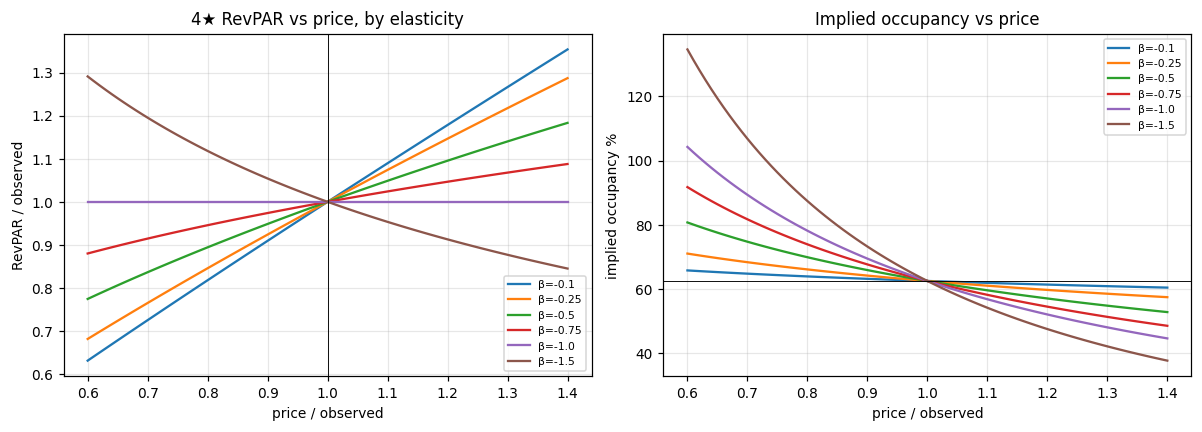

  [07_dynpricing] degenerate_optimum     |β|<1 → revenue rises monotonically in P           interior optimum needs marginal cost (unavailable) → we compare indexation rules, not a point optimum


In [2]:
m = df[(df.hotel_category == "stars_4") & (df.date >= TEST_START)]
p0 = m["average_rate"].median()
q0 = m["room_occupancy"].median() / 100
mult = np.linspace(0.6, 1.4, 81)
i1 = int(np.argmin(np.abs(mult - 1)))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for b in BETA_GRID:
    rev = (p0 * mult) * (q0 * mult**b)
    ax[0].plot(mult, rev / rev[i1], label=f"β={b}")
ax[0].axvline(1, color="k", lw=.6); ax[0].set_xlabel("price / observed")
ax[0].set_ylabel("RevPAR / observed"); ax[0].set_title("4★ RevPAR vs price, by elasticity")
ax[0].legend(fontsize=7)
for b in BETA_GRID:
    occ = q0 * mult**b * 100
    ax[1].plot(mult, occ, label=f"β={b}")
ax[1].axhline(q0*100, color="k", lw=.6); ax[1].set_xlabel("price / observed")
ax[1].set_ylabel("implied occupancy %"); ax[1].set_title("Implied occupancy vs price")
ax[1].legend(fontsize=7)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "07_revenue_curves.png")
LOG.log("figure", "07_revenue_curves.png"); plt.show()
LOG.log("degenerate_optimum", "|β|<1 → revenue rises monotonically in P",
        detail="interior optimum needs marginal cost (unavailable) → we compare indexation rules, not a point optimum")

## 2 · Pass-through policy paths (counterfactual, test window 2023-01 → 2026-05)

All policies start from the **observed** nominal rate at `TEST_START` (the
anchor) and set every subsequent month using **information available at t−1
only** (INDEC releases month-t CPI mid-month t+1, so month-t pricing can use CPI
through t−1). Counterfactual occupancy responds to the deviation of the policy
price from the observed price via the assumed β:

`occ_policy_t = occ_obs_t · (P_policy_t / P_obs_t)^β`  → `RevPAR = P·occ/100`.

In [3]:
def build_paths(s, beta, k_partial, k_dyn, delta_occ):
    s = s.sort_values("date").reset_index(drop=True)
    t0 = s.index[s.date == pd.Timestamp(TEST_START)][0]
    pi = s["infl_mom_gba"].values / 100                         # month-t MoM inflation
    cpi = s["cpi_gba"].values
    p_obs = s["average_rate"].values
    occ_obs = s["room_occupancy"].values
    # seasonal occupancy index from PRE-test data (training) by calendar month
    tr = s[s.date < TEST_START]
    seas = (tr.groupby(tr.date.dt.month)["room_occupancy"].mean() /
            tr["room_occupancy"].mean()).to_dict()
    mon = s.date.dt.month.values

    P = {name: p_obs.copy().astype(float) for name in ["A_cpi", "C_partial", "D_dynamic"]}
    for name in P:
        P[name][:t0 + 1] = p_obs[:t0 + 1]
    for i in range(t0 + 1, len(s)):
        infl_lag = pi[i - 1] if np.isfinite(pi[i - 1]) else 0.0
        infl_exp = np.nanmean(pi[max(0, i - 3):i])              # trailing 3m, info ≤ t-1
        infl_exp = infl_exp if np.isfinite(infl_exp) else 0.0
        # A/B — index the anchor to CPI (full pass-through, real price ≈ const)
        P["A_cpi"][i] = p_obs[t0] * cpi[i - 1] / cpi[t0]        # uses CPI through t-1
        # C — partial pass-through on last month's inflation
        P["C_partial"][i] = P["C_partial"][i - 1] * (1 + k_partial * infl_lag)
        # D — expected inflation × seasonal tilt × occupancy tilt
        occ_trail = np.nanmean(occ_obs[max(0, i - 12):i])
        occ_norm = np.nanmean(occ_obs[max(0, i - 24):i]) if i > 12 else occ_trail
        tilt = 1 + delta_occ * np.tanh((occ_trail - occ_norm) / max(occ_norm, 1e-6) * 5)
        seas_adj = seas.get(mon[i], 1.0) / seas.get(mon[i - 1], 1.0)
        P["D_dynamic"][i] = P["D_dynamic"][i - 1] * (1 + k_dyn * infl_exp) * tilt * seas_adj

    out = {}
    idx = slice(t0, len(s))
    for name, path in P.items():
        ratio = path[idx] / p_obs[idx]
        occ_cf = occ_obs[idx] * ratio ** beta
        revpar = path[idx] * occ_cf / 100
        out[name] = pd.DataFrame({
            "date": s.date.values[idx], "P": path[idx], "P_obs": p_obs[idx],
            "occ_cf": occ_cf, "revpar": revpar,
            "real_P": path[idx] / cpi[idx] * 100})
    # baseline = observed
    out["baseline_obs"] = pd.DataFrame({
        "date": s.date.values[idx], "P": p_obs[idx], "P_obs": p_obs[idx],
        "occ_cf": occ_obs[idx], "revpar": p_obs[idx] * occ_obs[idx] / 100,
        "real_P": p_obs[idx] / cpi[idx] * 100})
    return out


def summarise(paths, cat, beta):
    b = paths["baseline_obs"]["revpar"].sum()
    rows = []
    for name, d in paths.items():
        rows.append(dict(
            hotel_category=cat, label=LAB[cat], beta=beta, policy=name,
            mean_nominal_P=d["P"].mean(), mean_real_P=d["real_P"].mean(),
            sd_real_P=d["real_P"].std(), mean_occ=d["occ_cf"].mean(),
            total_revpar=d["revpar"].sum(),
            revpar_vs_baseline_pct=(d["revpar"].sum() / b - 1) * 100,
            down_months=int((d["revpar"].values[1:] < d["revpar"].values[:-1]).sum()),
        ))
    return rows

## 3 · Table 4 — policy comparison (anchored β, k_partial=0.6, k_dyn=1.0, δ_occ=0.03)

These `k`/`δ` values are placeholders for illustration; **nb08 selects them by
validation** and runs the proper walk-forward, no-look-ahead backtest.

In [4]:
allrows = []
for cat in CATS:
    s = df[df.hotel_category == cat]
    if s[s.date >= TEST_START].empty:
        continue
    paths = build_paths(s, BETA_ANCHOR[cat], k_partial=0.6, k_dyn=1.0, delta_occ=0.03)
    allrows += summarise(paths, cat, BETA_ANCHOR[cat])
tab4 = pd.DataFrame(allrows)
tab4.to_csv(C.OUT_TAB / "table4_policy_comparison.csv", index=False)
LOG.log("write", "table4_policy_comparison.csv", len(tab4))
tab4.pivot_table(index=["hotel_category", "label"], columns="policy",
                 values="revpar_vs_baseline_pct").round(2)

  [07_dynpricing] write                  table4_policy_comparison.csv           24  


,policy,A_cpi,C_partial,D_dynamic,baseline_obs
hotel_category,label,,,,
apart,Apart-hotel,-7.58,-23.74,11.11,0.0
boutique,Boutique,9.32,-34.65,43.25,0.0
stars_1_2,1-2 star,-9.61,-37.96,8.76,0.0
stars_3,3 star,4.44,-29.25,31.73,0.0
stars_4,4 star,-11.83,-41.91,16.51,0.0
stars_5,5 star,-10.73,-46.89,39.65,0.0


## 4 · Sweep the partial-pass-through coefficient k  (Policy C)

For each category and each assumed β, the k that maximises test-window RevPAR.
With |β| < 1 this is monotone (higher k → higher RevPAR up to the real-price
ceiling we allow); with |β| > 1 an interior k appears.

In [5]:
ks = np.round(np.arange(0.0, 1.61, 0.1), 2)
sweep = []
for cat in CATS:
    s = df[df.hotel_category == cat]
    if s[s.date >= TEST_START].empty:
        continue
    for beta in BETA_GRID:
        best_k, best_r = None, -np.inf
        for k in ks:
            paths = build_paths(s, beta, k_partial=k, k_dyn=1.0, delta_occ=0.03)
            r = paths["C_partial"]["revpar"].sum() / paths["baseline_obs"]["revpar"].sum() - 1
            if r > best_r:
                best_r, best_k = r, k
        sweep.append(dict(hotel_category=cat, label=LAB[cat], beta=beta,
                          k_star=best_k, revpar_gain_pct=round(best_r * 100, 2)))
sweep = pd.DataFrame(sweep)
sweep.pivot_table(index=["hotel_category", "label"], columns="beta", values="k_star")

,beta,-1.50,-1.00,-0.75,-0.50,-0.25,-0.10
hotel_category,label,,,,,,
apart,Apart-hotel,0.0,0.0,1.6,1.6,1.6,1.6
boutique,Boutique,0.0,0.0,1.6,1.6,1.6,1.6
stars_1_2,1-2 star,0.0,0.0,1.6,1.6,1.6,1.6
stars_3,3 star,0.0,0.0,1.6,1.6,1.6,1.6
stars_4,4 star,0.0,0.0,1.6,1.6,1.6,1.6
stars_5,5 star,0.0,0.2,1.6,1.6,1.6,1.6


## 5 · Chart D — "The optimal pass-through differs by hotel category"

  [07_dynpricing] figure                 07_chartD_optimal_passthrough.png           


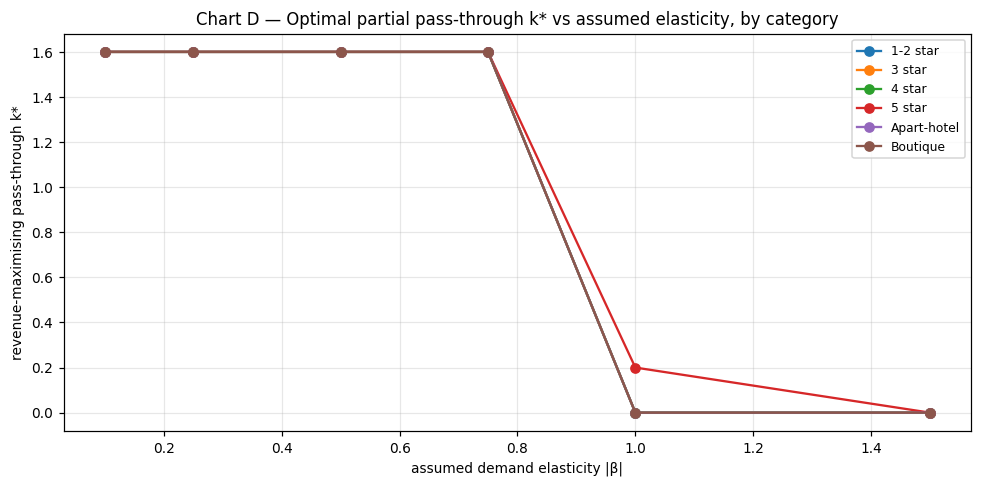

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for cat in CATS:
    d = sweep[sweep.hotel_category == cat]
    ax.plot(-d["beta"], d["k_star"], marker="o", label=LAB[cat])
ax.set_xlabel("assumed demand elasticity |β|")
ax.set_ylabel("revenue-maximising pass-through k*")
ax.set_title("Chart D — Optimal partial pass-through k* vs assumed elasticity, by category")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "07_chartD_optimal_passthrough.png")
LOG.log("figure", "07_chartD_optimal_passthrough.png"); plt.show()

## 6 · Chart E — dynamic policy vs mechanical CPI indexing (4★, anchored β)

  [07_dynpricing] figure                 07_chartE_dynamic_vs_indexing.png           


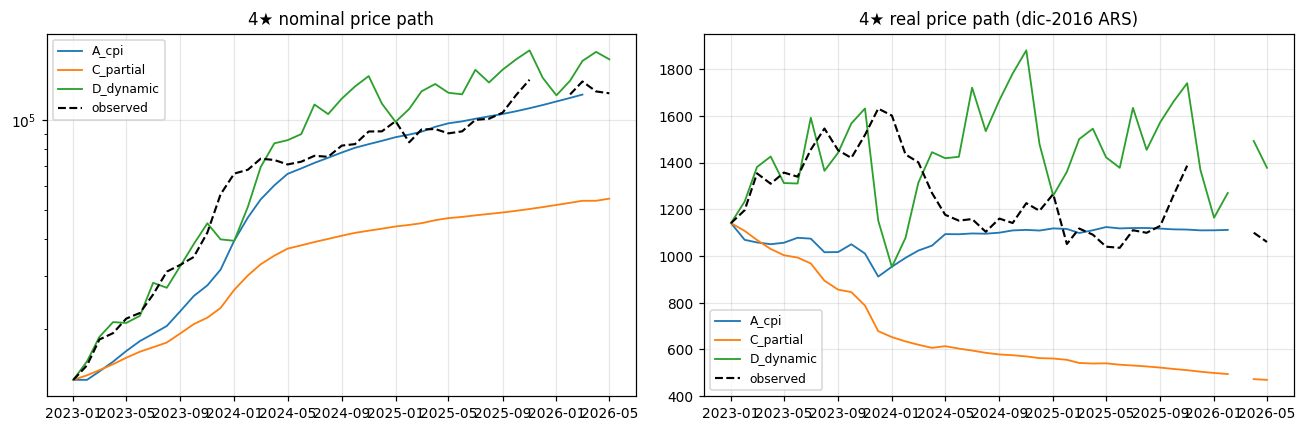

In [7]:
s = df[df.hotel_category == "stars_4"]
paths = build_paths(s, BETA_ANCHOR["stars_4"], 0.6, 1.0, 0.03)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, d in paths.items():
    if name == "baseline_obs":
        ax[0].plot(d.date, d.P, "k--", lw=1.4, label="observed")
        ax[1].plot(d.date, d.real_P, "k--", lw=1.4, label="observed")
    else:
        ax[0].plot(d.date, d.P, lw=1.2, label=name)
        ax[1].plot(d.date, d.real_P, lw=1.2, label=name)
ax[0].set_yscale("log"); ax[0].set_title("4★ nominal price path"); ax[0].legend(fontsize=8)
ax[1].set_title("4★ real price path (dic-2016 ARS)"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "07_chartE_dynamic_vs_indexing.png")
LOG.log("figure", "07_chartE_dynamic_vs_indexing.png"); plt.show()

In [8]:
LOG.flush()
print("07 complete.")

07 complete.
